# D2C Customer Churn - Part 2: RFM Segmentation

## Objective
The objective of this project is to segment customers using the RFM framework (Recency, Frequency, Monetary) and analyze churn behavior across customer segments.

## Steps Performed
1. Data loading and preprocessing
2. Leakage removal
3. RFM calculation
4. RFM scoring
5. Customer segmentation
6. Churn analysis
7. Retention strategy recommendations

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv('/content/customers.csv')
orders = pd.read_csv('/content/orders.csv')
churn = pd.read_csv('/content/churn_labels.csv')

In [46]:
orders['order_date'] = pd.to_datetime(
    orders['order_date']
)

In [47]:
snapshot_date = pd.Timestamp('2025-09-30')

In [48]:
orders_pre = orders[
    orders['order_date'] <= snapshot_date
].copy()

In [49]:
recency = (
    snapshot_date -
    orders_pre.groupby('customer_id')['order_date']
    .max()
).dt.days

In [50]:
frequency = (
    orders_pre.groupby('customer_id')
    .size()
)

In [51]:
monetary = (
    orders_pre.groupby('customer_id')
    ['gross_amount']
    .sum()
)


In [52]:
rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
}).reset_index()

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,CUST00001,107,6,2955.57
1,CUST00002,40,1,581.00
2,CUST00003,171,1,649.98
3,CUST00004,131,1,1604.04
4,CUST00005,38,4,2550.91


In [53]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

In [54]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,CUST00001,107,6,2955.57,2,5,4,254
1,CUST00002,40,1,581.00,4,1,1,411
2,CUST00003,171,1,649.98,1,1,1,111
3,CUST00004,131,1,1604.04,2,1,3,213
4,CUST00005,38,4,2550.91,4,3,3,433


In [55]:
rfm.describe()

,Recency,Frequency,Monetary
count,2400.000000,2400.000000,2400.000000
mean,87.375833,3.390417,2549.655729
std,80.137473,2.383350,2129.104340
min,0.000000,1.000000,149.000000
25%,25.000000,1.000000,955.380000
50%,66.000000,3.000000,2012.020000
75%,129.000000,5.000000,3566.080000
max,562.000000,16.000000,27215.920000


In [56]:
rfm['RFM_Total'] = (
    rfm['R_Score'].astype(int) +
    rfm['F_Score'].astype(int) +
    rfm['M_Score'].astype(int)
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,CUST00001,107,6,2955.57,2,5,4,254,11
1,CUST00002,40,1,581.00,4,1,1,411,6
2,CUST00003,171,1,649.98,1,1,1,111,3
3,CUST00004,131,1,1604.04,2,1,3,213,6
4,CUST00005,38,4,2550.91,4,3,3,433,10


In [57]:
def segment_customer(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalists'
    else:
        return 'At Risk'

rfm['Segment'] = rfm['RFM_Total'].apply(segment_customer)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment
0,CUST00001,107,6,2955.57,2,5,4,254,11,Loyal Customers
1,CUST00002,40,1,581.00,4,1,1,411,6,At Risk
2,CUST00003,171,1,649.98,1,1,1,111,3,At Risk
3,CUST00004,131,1,1604.04,2,1,3,213,6,At Risk
4,CUST00005,38,4,2550.91,4,3,3,433,10,Loyal Customers


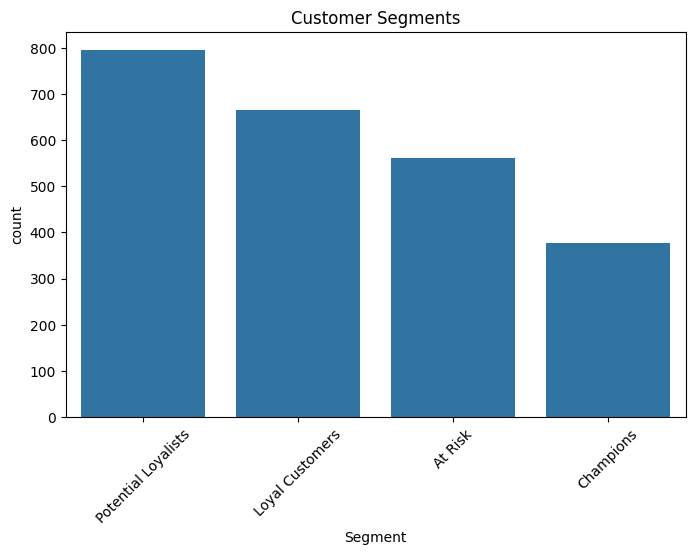

In [58]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x='Segment',
    order=rfm['Segment'].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Customer Segments")
plt.show()

## Customer Segmentation Insight

Customers have been segmented based on their purchase recency, frequency, and monetary value. Champions represent highly valuable customers, while At Risk customers require immediate retention efforts.


In [59]:
rfm = rfm.merge(
    churn,
    on='customer_id',
    how='left'
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment,snapshot_date,churn_next_60d,split
0,CUST00001,107,6,2955.57,2,5,4,254,11,Loyal Customers,2025-09-30,1,train
1,CUST00002,40,1,581.00,4,1,1,411,6,At Risk,2025-09-30,0,train
2,CUST00003,171,1,649.98,1,1,1,111,3,At Risk,2025-09-30,1,train
3,CUST00004,131,1,1604.04,2,1,3,213,6,At Risk,2025-09-30,1,train
4,CUST00005,38,4,2550.91,4,3,3,433,10,Loyal Customers,2025-09-30,0,train


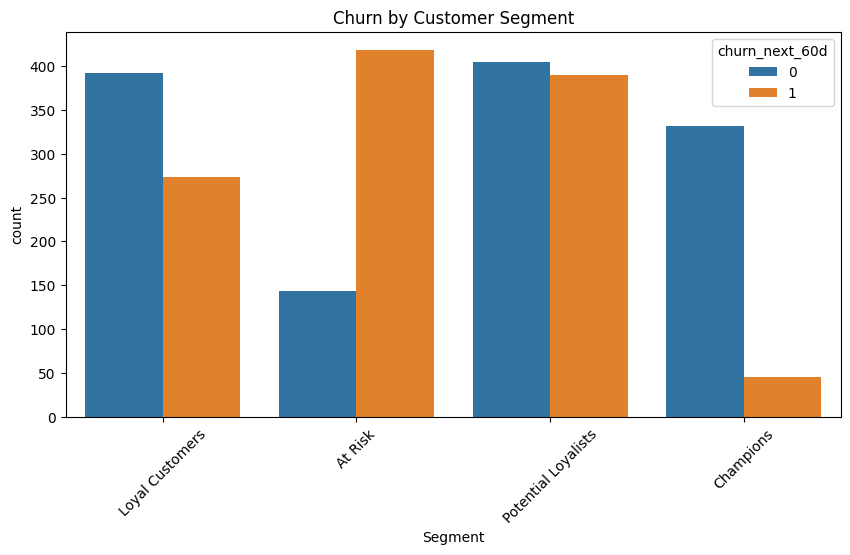

In [60]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=rfm,
    x='Segment',
    hue='churn_next_60d'
)

plt.xticks(rotation=45)
plt.title("Churn by Customer Segment")
plt.show()

## Churn Analysis by Segment

At Risk customers exhibit higher churn rates compared to Champions. This suggests that retention campaigns should focus primarily on At Risk and Potential Loyalists while rewarding Champions.
